In [1]:
import numpy as np
import pandas as pd 
from sklearn.model_selection import train_test_split
from faker import Faker
np.random.seed(42)
#load data

In [84]:
## fake name genrator
global fake_name
fake_name=[]
fake = Faker()
global student_df
end =1000
for _ in range(end) :
    fake_name.append(fake.name())

student_dfF=pd.read_csv(r"D:\learingAndDev\Own_application\Gen_AI_Learnings\Learinings\ML_BASICS\Data_science_library\data_sets\std.csv")
student_df=student_dfF[0:end]
student_col=student_df.columns.tolist()
student_df['student_Id']=np.array(np.random.randint(1,10000))
student_df['student_name']=pd.DataFrame(fake_name)

In [60]:

from sklearn.model_selection import train_test_split

## feature based on subject mark and grade finding the student name
X_feature=student_df[["Math","Science","English","Computer","Social"]]

from sklearn.impute import SimpleImputer
sim_impu = SimpleImputer(strategy='median')
X_feature = sim_impu.fit_transform(X_feature)

Y_output=student_df[["Average"]]
Y_output = sim_impu.fit_transform(Y_output)

X_train,X_test,Y_train,Y_test=train_test_split(X_feature,Y_output,test_size=0.2,random_state=42)
#print(len(X_train) , len(X_test))


In [61]:
## FEATURE SCALING
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
fit_check=scaler.fit_transform(X_train)
fit_check[0:1]


array([[ 0.1192537 , -0.21076662, -0.14417018, -0.00874095, -0.08578473]])

In [82]:
##CREATE MODEL
from sklearn.linear_model import LinearRegression

linear_model=LinearRegression()
linear_model.fit(X_train,Y_train)
print("\nLearned Weights:")
print(linear_model.coef_)

print("\nBias / Intercept:")
print(linear_model.intercept_)
print()

##model predict 
pred=linear_model.predict(X_test)
#print(pred)

##marks
# X_feature=student_df[["Math","Science","English","Computer","Social"]]
test_mark= [[30,30,30,30,20]]
pred_new=linear_model.predict(test_mark)
print("Aveerage : ",pred_new)



Learned Weights:
[[0.21350073 0.17878725 0.18700574 0.22240843 0.2058398 ]]

Bias / Intercept:
[-0.30837963]

Aveerage :  [[27.85948091]]


20


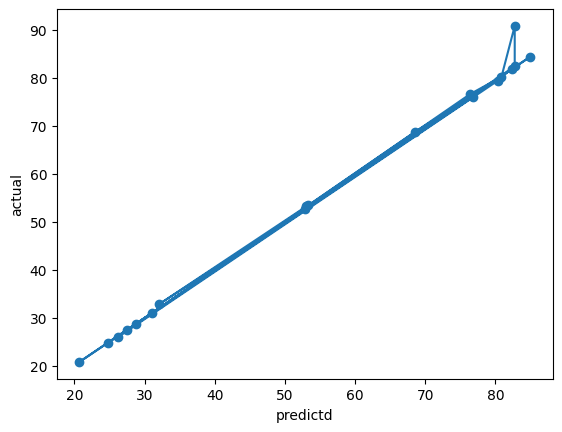

In [ ]:
import matplotlib.pyplot as plt
# Sort values for smooth line
##pred = linear_model.predict(X_test)
print(len(pred))

plt.scatter(pred,Y_test)
plt.plot(pred,Y_test)

plt.xlabel("predictd")
plt.ylabel("actual")
plt.show()
